In [8]:
#import libraries

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import time

print("Libraries Loaded Sucessfully")

Libraries Loaded Sucessfully


In [9]:
#load data

print("Loading")

X_train = pd.read_csv('../data/processed/X_train_clean.csv')
X_val = pd.read_csv('../data/processed/X_val_clean.csv')
y_train = pd.read_csv('../data/processed/y_train_clean.csv').squeeze()
y_val = pd.read_csv('../data/processed/y_val_clean.csv').squeeze()

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape: {y_val.shape}")
print("\nData Loaded Sucessfully")

Loading
X_train shape: (1980568, 71)
X_val shape: (423051, 71)
y_train shape: (1980568,)
y_val shape: (423051,)

Data Loaded Sucessfully


In [10]:
# random forest training
print("Training Random Forest")

start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators= 100, #no of tree
    max_depth=20, 
    random_state=42,
    n_jobs=-1,
    class_weight='balanced', #handeling imbalance
    verbose=1
)

rf_model.fit(X_train, y_train)

training_time = time.time() - start_time
print(f"\nTraining completed in {training_time:.2f} seconds.")

Training Random Forest


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 11 concurrent workers.
[Parallel(n_jobs=-1)]: Done  28 tasks      | elapsed:   27.9s



Training completed in 101.86 seconds.


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.6min finished


In [11]:
# Evaluating models on validation set
print("Model Evaluation")

y_pred = rf_model.predict(X_val)

print("\nClassification Report: ")
print(classification_report(y_val, y_pred, digits = 4))

[Parallel(n_jobs=11)]: Using backend ThreadingBackend with 11 concurrent workers.


Model Evaluation


[Parallel(n_jobs=11)]: Done  28 tasks      | elapsed:    0.3s
[Parallel(n_jobs=11)]: Done 100 out of 100 | elapsed:    0.8s finished



Classification Report: 
                            precision    recall  f1-score   support

                    BENIGN     0.9999    0.9953    0.9976    339790
                       Bot     0.1978    0.9795    0.3291       293
                      DDoS     0.9998    0.9997    0.9998     19153
             DoS GoldenEye     0.9955    0.9948    0.9951      1540
                  DoS Hulk     0.9923    0.9997    0.9960     34427
          DoS Slowhttptest     0.9903    0.9927    0.9915       823
             DoS slowloris     0.9931    0.9919    0.9925       867
               FTP-Patator     0.9992    1.0000    0.9996      1187
                Heartbleed     1.0000    1.0000    1.0000         2
              Infiltration     1.0000    0.6000    0.7500         5
                  PortScan     0.9940    0.9997    0.9968     23757
               SSH-Patator     1.0000    0.9989    0.9994       882
  Web Attack - Brute Force     0.7971    0.7333    0.7639       225
Web Attack - Sql Injec

# Random Forest Results — Retrained on Clean 71-Column Data

## Key Metrics Explained

| Metric | Meaning |
|--------|---------|
| **Precision** | Of everything the model called an attack, how many were actually attacks? |
| **Recall** | Of all real attacks, how many did the model catch? Most important for IDS — a missed attack is a real breach. |
| **F1-Score** | Balance between Precision and Recall. |
| **Support** | Number of actual samples of that class in the validation set. |

---

## Key Findings

| Class | Precision | Recall | F1 | Verdict |
|-------|-----------|--------|----|---------|
| DDoS | 1.00 | 1.00 | 1.00 | Excellent |
| DoS Hulk | 0.99 | 1.00 | 1.00 | Excellent |
| FTP-Patator | 1.00 | 1.00 | 1.00 | Excellent |
| SSH-Patator | 1.00 | 1.00 | 1.00 | Excellent |
| Heartbleed | 1.00 | 1.00 | 1.00 | Perfect — but only 2 samples in validation |
| Infiltration | 1.00 | 0.60 | 0.75 | Missed 40% of real Infiltration attacks |
| Bot | 0.20 | 0.98 | 0.33 | Catches most Bots but 80% of Bot predictions are false alarms |
| Web Attack - XSS | 0.49 | 0.56 | 0.52 | ~52% F1 — barely better than a coin flip |
| Web Attack - Brute Force | 0.80 | 0.73 | 0.76 | Missing 27% of real Brute Force attacks |
| Web Attack - SQL Injection | 0.00 | 0.00 | 0.00 | Completely blind — missed every single SQL Injection attack |

---

## Critical Insight

**Overall accuracy = 99.59% — but this number is misleading.**

SQL Injection Recall = 0.00 means the model failed to detect a single SQL Injection attack out of 3 in the validation set. In a real network, every one of those attacks would succeed undetected.

This is the core problem this project addresses: **weighted-average accuracy hides catastrophic failures on rare attack classes.**

---

## Why These Results Happen

Random Forest uses `class_weight='balanced'` to penalize mistakes on rare classes more heavily. But this is not enough when the class is extremely rare.

SQL Injection has only 21 samples in the full dataset. After a 70% train split, roughly 15 samples remain for training. With 100 trees each seeing a random subset of rows, most trees never see a SQL Injection sample at all. There is simply not enough signal to learn from.

`class_weight='balanced'` helps with mild imbalance. It does not solve extreme imbalance where one class has 15 training samples against 1.6 million BENIGN rows.

---

## Connection to IAA-Transformer

These results directly motivate the IAA-Transformer:

- **SMOTE** addresses the data-level problem by generating synthetic minority samples
- **IAA-Transformer** addresses the architecture-level problem by forcing the attention mechanism to pay more attention to rare classes during every forward pass

The goal is to move SQL Injection Recall from **0.00** to a meaningful detection rate — without sacrificing performance on the majority classes.

---

## Training Details

| Parameter | Value |
|-----------|-------|
| n_estimators | 100 |
| max_depth | 20 |
| class_weight | balanced |
| random_state | 42 |
| Training data | 1,980,568 rows, 71 columns |
| Training time | ~96 seconds |

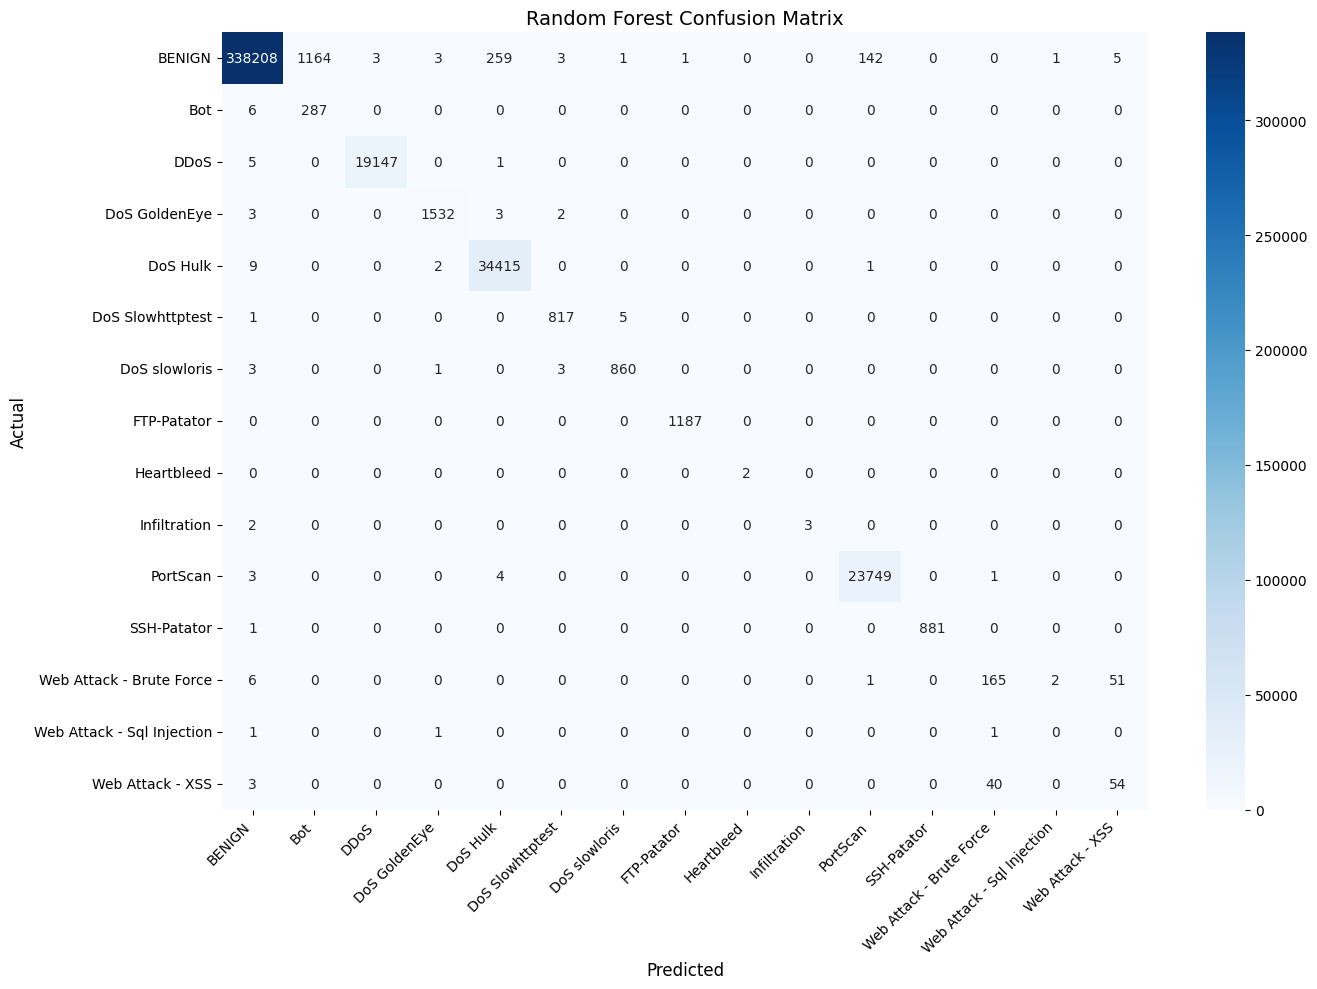

In [12]:
#confusion matrix plot
plt.figure(figsize=(14,10))
cm = confusion_matrix(y_val, y_pred, labels=rf_model.classes_)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=rf_model.classes_, yticklabels=rf_model.classes_, cmap= 'Blues')
plt.title('Random Forest Confusion Matrix', fontsize=14)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.xticks(rotation=45, ha= 'right')
plt.tight_layout()
plt.savefig('../results/rf_confusion_matrix.png', dpi=300, bbox_inches= 'tight')
plt.show()

/var/folders/zy/szwpfn290db_b_7d_thzbd700000gn/T/ipykernel_15504/2341952825.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance',


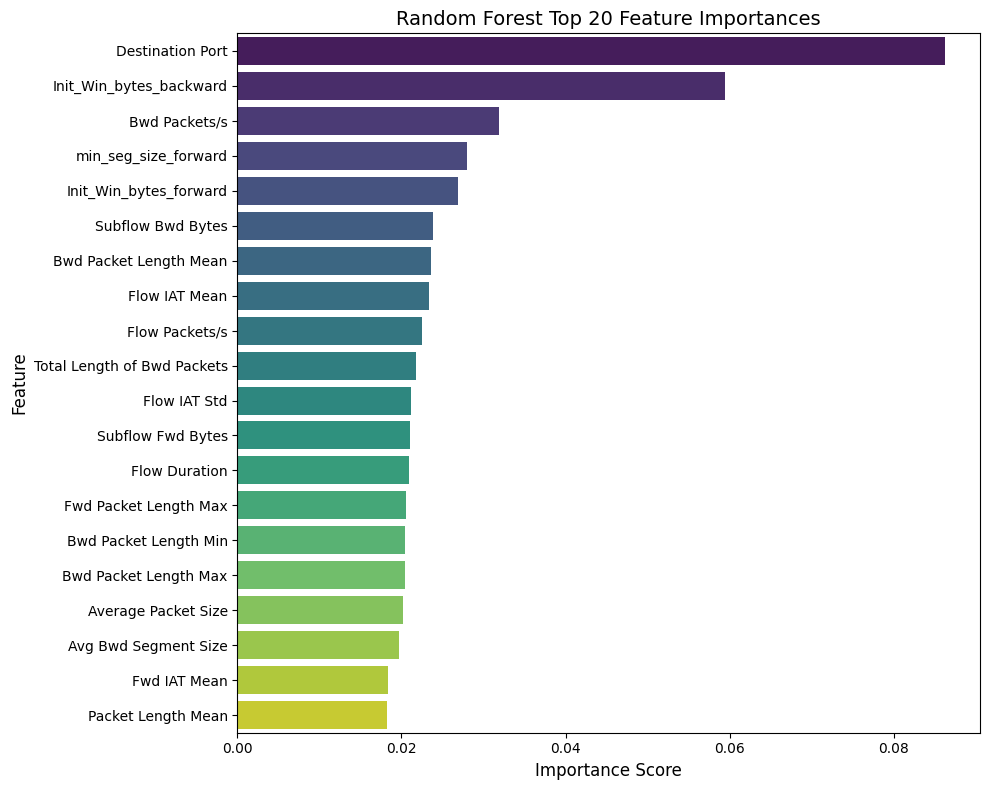


Top 10 Most Important Features:
                    feature  importance
           Destination Port    0.086218
    Init_Win_bytes_backward    0.059447
              Bwd Packets/s    0.031851
       min_seg_size_forward    0.027985
     Init_Win_bytes_forward    0.026878
          Subflow Bwd Bytes    0.023849
     Bwd Packet Length Mean    0.023642
              Flow IAT Mean    0.023391
             Flow Packets/s    0.022557
Total Length of Bwd Packets    0.021760


In [13]:
# Feature Importance
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', 
            y='feature', 
            data=feature_importance.head(20),
            palette='viridis')
plt.title('Random Forest Top 20 Feature Importances', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig('../results/rf_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

In [14]:
import joblib
joblib.dump(rf_model, '../models/random_forest_clean.pkl')
print("Model saved.")

Model saved.
